# pySCENIC GRN Inference Pipeline
### Hepatocytes → Cholangiocytes · GSE202379 · End-stage disease

**SCENIC pipeline — three steps:**
1. **GRN** — co-expression modules via GRNBoost2 (arboreto): TF → target adjacencies
2. **CTX** — motif enrichment via cisTarget: prune indirect targets, define regulons
3. **AUCell** — score regulon activity per cell; cluster on regulon activity matrix

**Required reference files (human hg38) — download once, ~2.3 GB total:**
| File | Size | What it is |
|---|---|---|
| `allTFs_hg38.txt` | ~50 KB | List of 1,839 human TF gene symbols |
| `motifs-v10nr_clust-nr.hgnc-m0.001-o0.0.tbl` | ~100 MB | Motif → TF annotation table |
| `hg38_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather` | ~1.1 GB | cisTarget ranking DB (10 kb window) |
| `hg38_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather` | ~1.1 GB | cisTarget ranking DB (500 bp window) |

Cell 0 will download all of these automatically.

> **Reference:** Van de Sande et al., *Nature Protocols* 2020; Aibar et al., *Nature Methods* 2017

---
## Cell 0 · Install pySCENIC + download reference files (run once)

Run this cell once, then **restart the kernel** before continuing.

In [ ]:
# import subprocess, sys, os

# # ── install pySCENIC and dependencies ────────────────────────────────────────
# # Use your scenic conda env kernel for this notebook (NOT the velorama kernel)
# subprocess.run([sys.executable, "-m", "pip", "install",
#                 "pyscenic", "loompy", "arboreto", "ctxcore",
#                 "dask", "distributed"], check=True)

# print("\n✅ pySCENIC installed")

# # ── paths ─────────────────────────────────────────────────────────────────────
# RESOURCES_DIR = r"C:/Users/Floarea/Desktop/corebioinfo/scenic_resources"
# os.makedirs(RESOURCES_DIR, exist_ok=True)

# # ── reference file URLs ───────────────────────────────────────────────────────
# files_to_download = {
#     # TF list (small, fast)
#     "allTFs_hg38.txt": 
#         "https://raw.githubusercontent.com/aertslab/SCENICprotocol/master/example/allTFs_hg38.txt",
    
#     # Motif annotation table (~100 MB)
#     "motifs-v10nr_clust-nr.hgnc-m0.001-o0.0.tbl":
#         "https://resources.aertslab.org/cistarget/motif2tf/motifs-v10nr_clust-nr.hgnc-m0.001-o0.0.tbl",

#     # cisTarget ranking databases (~1.1 GB each) — both windows recommended
#     "hg38_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather":
#         "https://resources.aertslab.org/cistarget/databases/homo_sapiens/hg38/refseq_r80/mc_v10_clust/gene_based/hg38_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather",

#     "hg38_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather":
#         "https://resources.aertslab.org/cistarget/databases/homo_sapiens/hg38/refseq_r80/mc_v10_clust/gene_based/hg38_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather",
# }

# import urllib.request

# for fname, url in files_to_download.items():
#     dest = os.path.join(RESOURCES_DIR, fname)
#     if os.path.isfile(dest):
#         print(f"  Already exists: {fname}")
#         continue
#     print(f"  Downloading {fname} ...")
#     urllib.request.urlretrieve(url, dest)
#     size_mb = os.path.getsize(dest) / 1e6
#     print(f"  ✅ {fname}  ({size_mb:.0f} MB)")

# print("\nAll reference files ready — RESTART KERNEL, then run from Cell 1")

---
## Cell 1 · Imports and paths

In [1]:
import os
import glob
import pickle

import numpy as np
import pandas as pd
import scanpy as sc
import loompy
import matplotlib.pyplot as plt
import seaborn as sns

# pySCENIC core imports
from arboreto.algo import grnboost2
from arboreto.utils import load_tf_names
from ctxcore.rnkdb import FeatherRankingDatabase as RankingDatabase
from pyscenic.utils import modules_from_adjacencies
from pyscenic.prune import prune2df, df2regulons
from pyscenic.aucell import aucell

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, facecolor="white")

# ── edit these paths if needed ───────────────────────────────────────────────
H5AD_PATH     = r"C:/Users/Floarea/Desktop/corebioinfo/R codes/data/GSE202379_fitlered.h5ad"
RESOURCES_DIR = r"C:/Users/Floarea/Desktop/corebioinfo/R codes/data/scenic_resources"
OUTPUT_DIR    = r"C:/Users/Floarea/Desktop/corebioinfo/R codes/data/scenic_output"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── reference file paths ─────────────────────────────────────────────────────
TF_LIST_PATH    = os.path.join(RESOURCES_DIR, "allTFs_hg38.txt")
MOTIF_ANN_PATH  = os.path.join(RESOURCES_DIR, "motifs-v10nr_clust-nr.hgnc-m0.001-o0.0.tbl")
DB_GLOB         = os.path.join(RESOURCES_DIR, "*.rankings.feather")

# ── output file paths (used across steps) ────────────────────────────────────
ADJACENCIES_PATH = os.path.join(OUTPUT_DIR, "adjacencies.tsv")
REGULONS_PATH    = os.path.join(OUTPUT_DIR, "regulons.pkl")
MOTIFS_PATH      = os.path.join(OUTPUT_DIR, "motifs.csv")
LOOM_INPUT_PATH  = os.path.join(OUTPUT_DIR, "expr_input.loom")
LOOM_OUTPUT_PATH = os.path.join(OUTPUT_DIR, "pyscenic_output.loom")
AUC_MTX_PATH     = os.path.join(OUTPUT_DIR, "auc_matrix.csv")

print("Paths configured.")
print(f"  TF list     : {os.path.isfile(TF_LIST_PATH)}")
print(f"  Motif annot : {os.path.isfile(MOTIF_ANN_PATH)}")
print(f"  Feather DBs : {len(glob.glob(DB_GLOB))} found")

Paths configured.
  TF list     : True
  Motif annot : True
  Feather DBs : 1 found


---
## Cell 2 · Load data and prepare expression matrix

pySCENIC requires **log-normalised** counts (not raw integers).  
We also need gene symbols (not Ensembl IDs) to match the TF list and feather DBs.

In [9]:
# ── Cell 2 replacement: load data + subsample to match Velorama ──────────────
import scipy.sparse as sp
import numpy as np

VELORAMA_H5AD = r"C:/Users/Floarea/Desktop/corebioinfo/velorama_output/liver_endstage.h5ad"

# Load the exact subsampled adata that was used for Velorama
# This guarantees both tools run on identical cells
adata = sc.read_h5ad(VELORAMA_H5AD)
print(f"Loaded Velorama subsample: {adata.n_obs} cells × {adata.n_vars} genes")
print("Cell annotations:", adata.obs["cell.annotation"].value_counts().to_dict())

# pySCENIC needs log-normalised data
# The Velorama adata.X was already log-normalised — check and use directly
# If it looks like raw counts (large integers), re-normalise
sample_vals = adata.X[:5].toarray() if sp.issparse(adata.X) else adata.X[:5]
if sample_vals.max() > 100:
    print("Re-normalising (raw counts detected)...")
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
else:
    print("Log-normalised data detected — using as-is")

print(f"\nExpression value range: {sample_vals.min():.2f} – {sample_vals.max():.2f}")

Loaded Velorama subsample: 300 cells × 191 genes
Cell annotations: {'Hepatocytes': 273, 'Cholangiocytes': 27}
Log-normalised data detected — using as-is

Expression value range: 0.00 – 3.47


---
## Cell 3 · Select highly variable genes

Running pySCENIC on all 30k+ genes is very slow. Restricting to the top 3,000–5,000  
highly variable genes is the standard practice from the SCENIC protocol paper.

In [10]:
# ── Cell 3 replacement: select genes + load TF list ──────────────────────────

tf_names   = load_tf_names(TF_LIST_PATH)
tf_in_data = [g for g in tf_names if g in adata.var_names]

# Use all genes in the subsample (already pre-filtered to HVGs + TFs by Velorama prep)
# This ensures the exact same gene set as Velorama
genes_use    = adata.var_names.tolist()
adata_scenic = adata[:, genes_use].copy()

print(f"TFs in reference list    : {len(tf_names)}")
print(f"TFs present in subsample : {len(tf_in_data)}")
print(f"Total genes              : {len(genes_use)}")
print(f"adata_scenic             : {adata_scenic.n_obs} cells × {adata_scenic.n_vars} genes")

TFs in reference list    : 1892
TFs present in subsample : 49
Total genes              : 191
adata_scenic             : 300 cells × 191 genes


---
## Cell 4 · Build expression matrix and save as loom

pySCENIC steps 2 & 3 (CTX and AUCell) use the loom format.  
We build the expression DataFrame here and reuse it throughout.

In [13]:
# ── Cell 4 replacement: build expression matrix + loom ───────────────────────

X_dense = adata_scenic.X.toarray() if sp.issparse(adata_scenic.X) else np.array(adata_scenic.X)
ex_matrix = pd.DataFrame(
    X_dense,
    index   = adata_scenic.obs_names,
    columns = adata_scenic.var_names
)
print(f"Expression matrix: {ex_matrix.shape}  (cells × genes)")

# Cast all attributes to plain numpy arrays — loompy rejects pandas Categoricals
row_attrs = {
    "Gene": np.array(adata_scenic.var_names, dtype=str)
}
col_attrs = {
    "CellID":          np.array(adata_scenic.obs_names, dtype=str),
    "cell_annotation": np.array(adata_scenic.obs["cell.annotation"].astype(str)),
}

# Remove existing loom if present (loompy won't overwrite cleanly)
if os.path.isfile(LOOM_INPUT_PATH):
    os.remove(LOOM_INPUT_PATH)

loompy.create(LOOM_INPUT_PATH, X_dense.T, row_attrs, col_attrs)
print(f"✅ Loom saved: {LOOM_INPUT_PATH}")

Expression matrix: (300, 191)  (cells × genes)
✅ Loom saved: C:/Users/Floarea/Desktop/corebioinfo/R codes/data/scenic_output\expr_input.loom


---
## Cell 5 · Step 1 — GRN: co-expression modules via GRNBoost2

GRNBoost2 (gradient-boosted trees) infers TF → target importance scores  
from co-expression across cells. This is the **fastest** of the three SCENIC steps.

**Runtime:** ~5–15 min for 3,000 cells × 3,000 genes on 4 CPU workers.

In [16]:
# ── delete stale adjacencies and rerun GRNBoost2 on the subsample ─────────────
import os

# Remove cached files from any previous full-dataset run
for stale in [ADJACENCIES_PATH, REGULONS_PATH, MOTIFS_PATH]:
    if os.path.isfile(stale):
        os.remove(stale)
        print(f"Deleted: {stale}")

print(f"\nRunning GRNBoost2 on subsample: "
      f"{ex_matrix.shape[0]} cells × {ex_matrix.shape[1]} genes ...")
print(f"TF regulators: {len(tf_in_data)}\n")

adjacencies = grnboost2(
    expression_data = ex_matrix,
    tf_names        = tf_in_data,
    verbose         = True,
    seed            = 42,
)

adjacencies.to_csv(ADJACENCIES_PATH, sep="\t", index=False)
print(f"\n✅ Adjacencies saved: {ADJACENCIES_PATH}")
print(f"Shape: {adjacencies.shape}")
print(adjacencies.nlargest(10, "importance").to_string(index=False))

Deleted: C:/Users/Floarea/Desktop/corebioinfo/R codes/data/scenic_output\adjacencies.tsv

Running GRNBoost2 on subsample: 300 cells × 191 genes ...
TF regulators: 49

preparing dask client
parsing input
creating dask graph
4 partitions
computing dask graph
shutting down client and local cluster
finished

✅ Adjacencies saved: C:/Users/Floarea/Desktop/corebioinfo/R codes/data/scenic_output\adjacencies.tsv
Shape: (7003, 3)
   TF     target  importance
PPARG      FCRL1   15.108538
 PBX1       MUC1   13.335372
PPARG AC099792.1   10.470212
PPARG    FAM102B    9.491973
CEBPB      AJAP1    9.245208
 PBX1    SLC44A3    8.734135
HNF1B  LINC01781    8.672824
PPARG       DNM3    8.318854
PPARG     S100A6    8.298822
NR5A2       ORC1    8.195940


---
## Cell 6 · Step 2 — CTX: motif enrichment → prune regulons

cisTarget cross-references the co-expression modules from Step 1 against  
a genome-wide regulatory feature database to keep only **direct** TF–target links  
(i.e. those with a matching TF binding motif in the target's promoter/enhancer).

**Runtime:** ~20–60 min per feather DB on CPU. The two DBs run sequentially.

In [17]:
# ── Cell 6 replacement: CTX pruning (mask_dropouts removed) ──────────────────
import dask.diagnostics
from pyscenic.utils import modules_from_adjacencies
from pyscenic.prune import prune2df, df2regulons

db_files = sorted(glob.glob(DB_GLOB))
print(f"Feather databases: {len(db_files)}")
dbs = [RankingDatabase(fname=f, name=os.path.basename(f).split(".")[0])
       for f in db_files]

modules = list(modules_from_adjacencies(adjacencies, ex_matrix))
print(f"Co-expression modules: {len(modules)}")

if os.path.isfile(REGULONS_PATH):
    print(f"Loading existing regulons from {REGULONS_PATH}")
    with open(REGULONS_PATH, "rb") as f:
        regulons = pickle.load(f)
else:
    print("Running cisTarget pruning ...")
    with dask.diagnostics.ProgressBar():
        df_motifs = prune2df(
            dbs,
            modules,
            MOTIF_ANN_PATH,
            num_workers = 4,    # remove mask_dropouts — not supported in this version
        )

    regulons = df2regulons(df_motifs)
    df_motifs.to_csv(MOTIFS_PATH)
    with open(REGULONS_PATH, "wb") as f:
        pickle.dump(regulons, f)
    print(f"✅ Regulons saved: {REGULONS_PATH}")

print(f"\nRegulons: {len(regulons)}")
for reg in sorted(regulons, key=lambda r: -len(r.gene2weight))[:10]:
    print(f"  {reg.name:20s}  {len(reg.gene2weight)} targets")

Feather databases: 1



2026-06-13 13:51:46,908 - pyscenic.utils - INFO - Calculating Pearson correlations.

2026-06-13 13:51:46,915 - pyscenic.utils - WARNING - Note on correlation calculation: the default behaviour for calculating the correlations has changed after pySCENIC verion 0.9.16. Previously, the default was to calculate the correlation between a TF and target gene using only cells with non-zero expression values (mask_dropouts=True). The current default is now to use all cells to match the behavior of the R verision of SCENIC. The original settings can be retained by setting 'rho_mask_dropouts=True' in the modules_from_adjacencies function, or '--mask_dropouts' from the CLI.
	Dropout masking is currently set to [False].

2026-06-13 13:51:47,076 - pyscenic.utils - INFO - Creating modules.
c:\Users\Floarea\miniconda3\envs\scenic\lib\site-packages\pyscenic\utils.py:244: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included

Co-expression modules: 200
Running cisTarget pruning ...
[########################################] | 100% Completed | 242.15 s
Create regulons from a dataframe of enriched features.
Additional columns saved: []
✅ Regulons saved: C:/Users/Floarea/Desktop/corebioinfo/R codes/data/scenic_output\regulons.pkl

Regulons: 16
  HNF1B(+)              24 targets
  GATA4(+)              21 targets
  KLF6(+)               18 targets
  RXRA(+)               18 targets
  HNF1A(+)              15 targets
  NFE2L2(+)             14 targets
  TCF7L2(+)             10 targets
  GATA6(+)              9 targets
  TEAD1(+)              8 targets
  ATF3(+)               6 targets


In [18]:
# ── prune modules with cisTarget motif enrichment ─────────────────────────────

import dask.diagnostics
# Skip if already done
if os.path.isfile(REGULONS_PATH):
    print(f"Loading existing regulons from {REGULONS_PATH}")
    with open(REGULONS_PATH, "rb") as f:
        regulons = pickle.load(f)
else:
    print("Running cisTarget pruning — this is the slow step (~20-60 min) ...")

    # prune2df: enrichment analysis against the feather ranking DBs
    with dask.diagnostics.ProgressBar():
        df_motifs = prune2df(
            dbs,
            modules,
            MOTIF_ANN_PATH,
            num_workers=4,         # increase if you have more CPU cores
            mask_dropouts=True,    # exclude genes expressed in <1% of cells
        )

    # Convert pruned motif table to Regulon objects
    regulons = df2regulons(df_motifs)

    # Save both the motif table and regulons
    df_motifs.to_csv(MOTIFS_PATH)
    with open(REGULONS_PATH, "wb") as f:
        pickle.dump(regulons, f)

    print(f"\n✅ Regulons saved: {REGULONS_PATH}")

print(f"\nRegulons identified: {len(regulons)}")
print("\nSample regulons (TF: n_targets):")
for reg in sorted(regulons, key=lambda r: -len(r.gene2weight))[:10]:
    print(f"  {reg.name:20s}  {len(reg.gene2weight)} targets")

Loading existing regulons from C:/Users/Floarea/Desktop/corebioinfo/R codes/data/scenic_output\regulons.pkl

Regulons identified: 16

Sample regulons (TF: n_targets):
  HNF1B(+)              24 targets
  GATA4(+)              21 targets
  KLF6(+)               18 targets
  RXRA(+)               18 targets
  HNF1A(+)              15 targets
  NFE2L2(+)             14 targets
  TCF7L2(+)             10 targets
  GATA6(+)              9 targets
  TEAD1(+)              8 targets
  ATF3(+)               6 targets


---
## Cell 7 · Step 3 — AUCell: score regulon activity per cell

AUCell scores how active each regulon is in each individual cell,  
producing a **cells × regulons** activity matrix used for downstream clustering.

In [ ]:
# Skip if AUC matrix already computed
if os.path.isfile(AUC_MTX_PATH):
    print(f"Loading existing AUC matrix from {AUC_MTX_PATH}")
    auc_mtx = pd.read_csv(AUC_MTX_PATH, index_col=0)
else:
    print(f"Running AUCell on {ex_matrix.shape[0]} cells × {len(regulons)} regulons ...")

    # aucell: area-under-the-curve enrichment score per cell per regulon
    # num_workers controls parallelism; auc_threshold auto-inferred
    auc_mtx = aucell(
        ex_matrix,
        regulons,
        auc_threshold = 0.05,   # top 5% of ranked genes counts as active
        num_workers   = 4,
    )

    auc_mtx.to_csv(AUC_MTX_PATH)
    print(f"\n✅ AUC matrix saved: {AUC_MTX_PATH}")

print(f"\nAUC matrix shape: {auc_mtx.shape}  (cells × regulons)")
print(auc_mtx.iloc[:4, :4])

Running AUCell on 300 cells × 16 regulons ...

✅ AUC matrix saved: C:/Users/Floarea/Desktop/corebioinfo/R codes/data/scenic_output\auc_matrix.csv

AUC matrix shape: (300, 16)  (cells × regulons)
Regulon               ATF3(+)  FOXA2(+)  FOXJ3(+)  GATA4(+)
Cell                                                       
TTGCGTCTCGCGTGAC-55  0.000000       0.0  0.118617  0.000000
TTTGTTGTCCGTTTCG-7   0.260453       0.0  0.013496  0.000000
CCGGACATCCATCCGT-14  0.000000       0.0  0.000000  0.000000
CACAACAGTTGTTGCA-55  0.000000       0.0  0.000000  0.010956


---
## Cell 8 · Add AUC scores back to AnnData

Storing the regulon activity matrix in `adata.obsm` lets us use  
all Scanpy visualisation tools on the regulon space.

In [20]:
# Align AUC matrix rows to adata cell order (they should match, but be safe)
auc_aligned = auc_mtx.reindex(adata_scenic.obs_names)

# Store in obsm
adata_scenic.obsm["X_scenic"] = auc_aligned.values

# Also store as individual obs columns for easy plotting
for col in auc_aligned.columns:
    adata_scenic.obs[f"AUC_{col}"] = auc_aligned[col].values

print(f"AUC scores added to adata_scenic.obsm['X_scenic']")
print(f"Shape: {adata_scenic.obsm['X_scenic'].shape}")

AUC scores added to adata_scenic.obsm['X_scenic']
Shape: (300, 16)


---
## Cell 9 · PCA + UMAP on regulon activity space

Cells are now embedded using **regulon activity** rather than raw gene expression.  
This often gives sharper cell-type separation because it captures TF-driven programs.

computing PCA
    with n_comps=15
    finished (0:00:00)
computing neighbors
    using data matrix X directly
    finished (0:00:00)
computing UMAP
    finished (0:00:01)
running Leiden clustering
    finished (0:00:00)


c:\Users\Floarea\miniconda3\envs\scenic\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
c:\Users\Floarea\miniconda3\envs\scenic\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


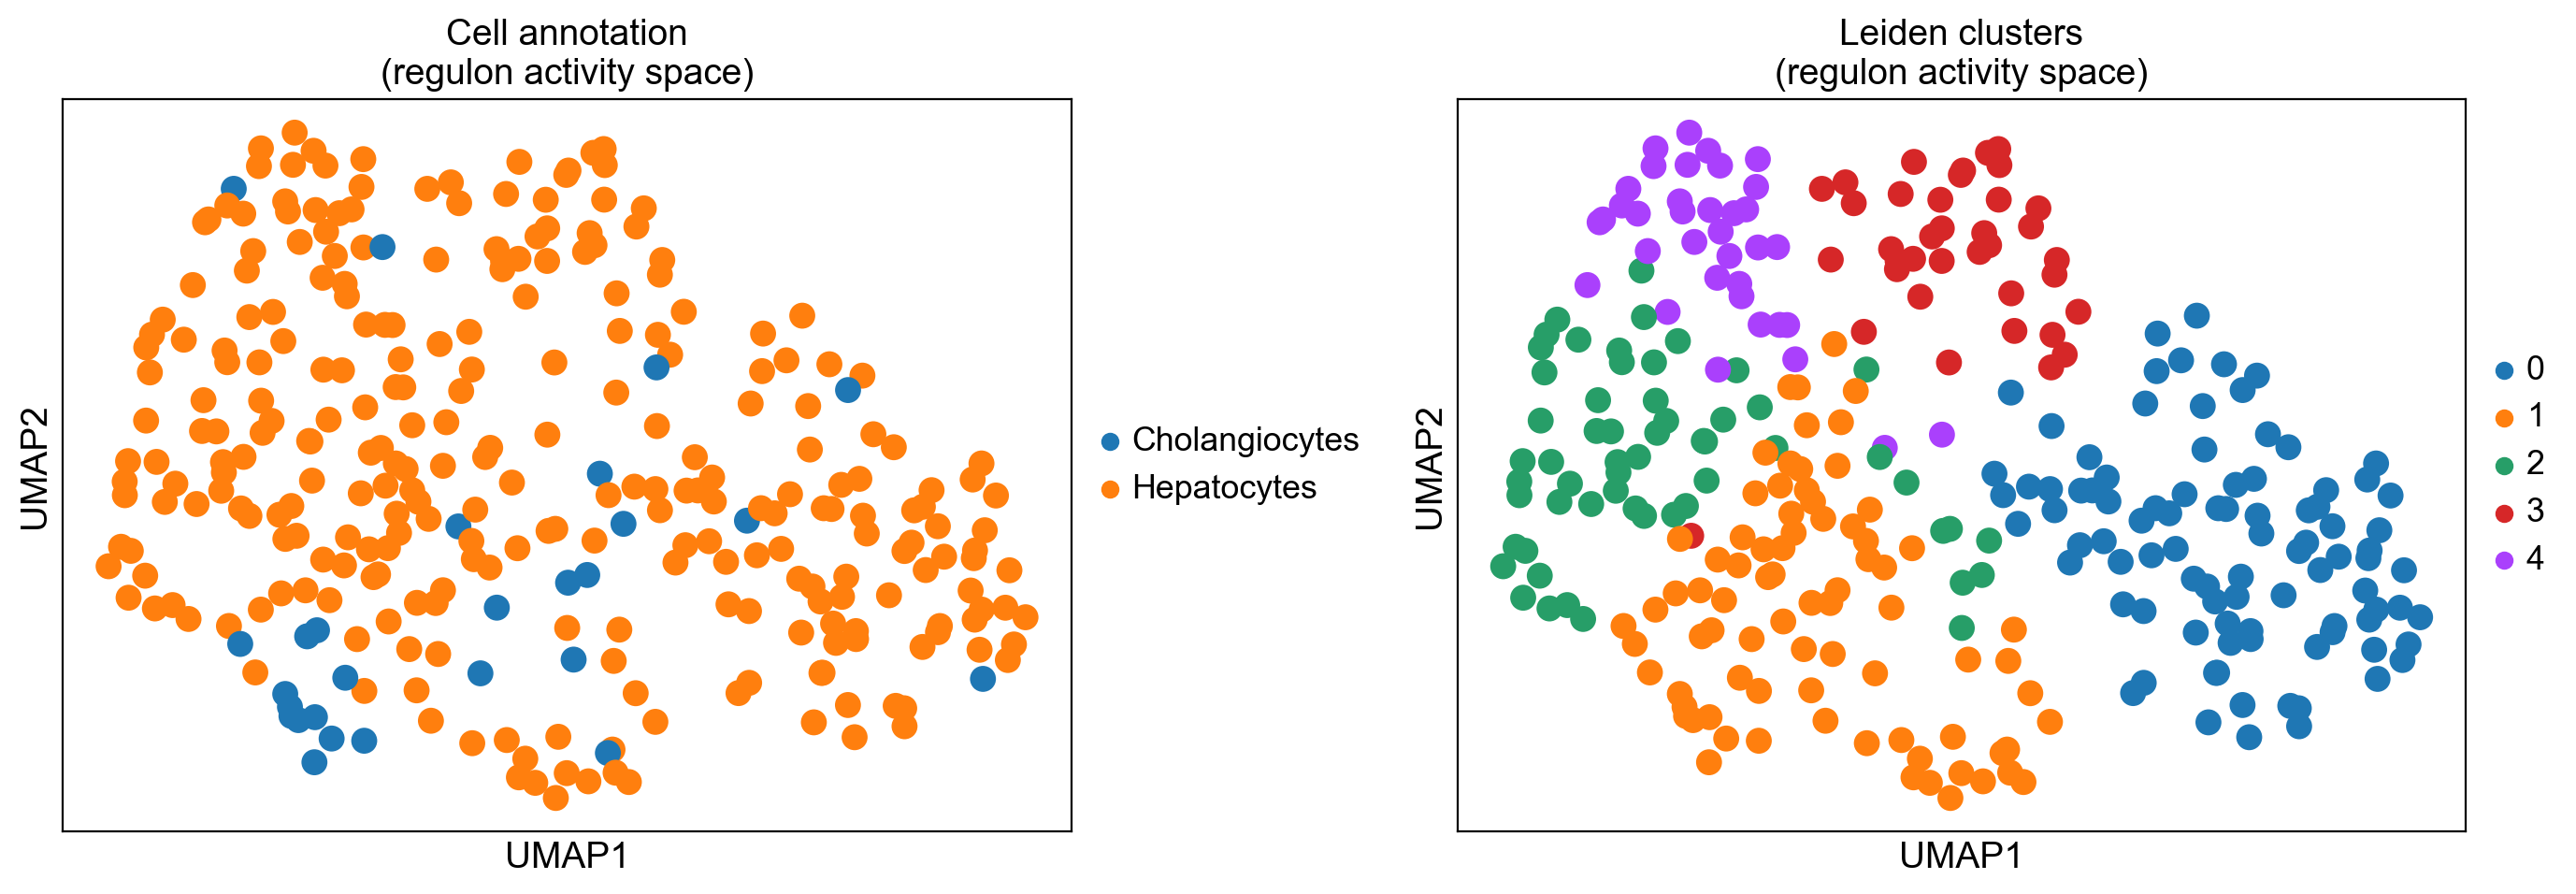

In [22]:
import anndata as ad

# Create a temporary AnnData using the AUC matrix as .X for dimensionality reduction
adata_auc = ad.AnnData(
    X   = auc_aligned.values,
    obs = adata_scenic.obs.copy(),
    var = pd.DataFrame(index=auc_aligned.columns)
)

# PCA on regulon activity space
sc.pp.scale(adata_auc)                          # standardise AUC scores
sc.pp.pca(adata_auc)
sc.pp.neighbors(adata_auc, n_neighbors=30)
sc.tl.umap(adata_auc)
sc.tl.leiden(adata_auc, resolution=0.5, key_added="leiden_scenic")

# Copy UMAP coordinates back to main adata
adata_scenic.obsm["X_umap_scenic"] = adata_auc.obsm["X_umap"]
adata_scenic.obs["leiden_scenic"]  = adata_auc.obs["leiden_scenic"].values

# Plot: SCENIC-space UMAP coloured by cell type and Leiden
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc.pl.embedding(adata_auc, basis="umap", color="cell.annotation",
                ax=axes[0], show=False, title="Cell annotation\n(regulon activity space)")
sc.pl.embedding(adata_auc, basis="umap", color="leiden_scenic",
                ax=axes[1], show=False, title="Leiden clusters\n(regulon activity space)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "umap_scenic_space.png"), dpi=150)
plt.show()

---
## Cell 10 · Visualisation 1 — Top regulons by mean activity

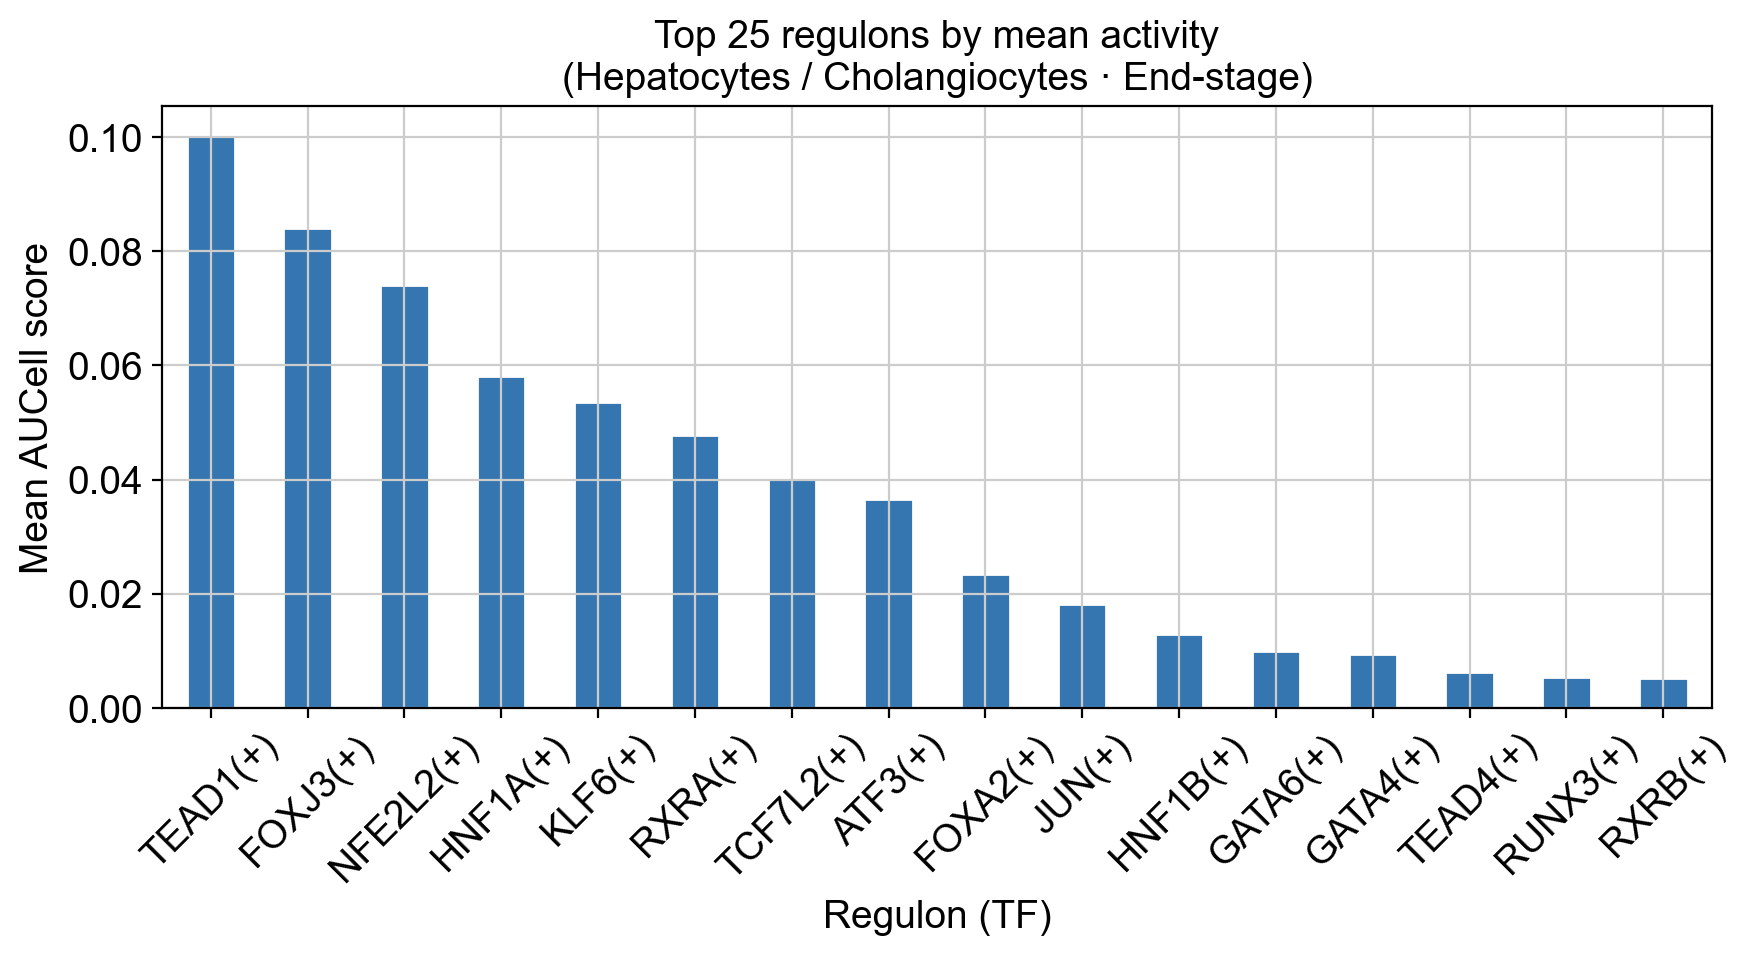

In [23]:
TOP_N = 25

# Mean AUC score per regulon across all cells
mean_auc = auc_mtx.mean(axis=0).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
mean_auc.head(TOP_N).plot(kind="bar", ax=ax, color="#3576b0", edgecolor="white")
ax.set_xlabel("Regulon (TF)")
ax.set_ylabel("Mean AUCell score")
ax.set_title(f"Top {TOP_N} regulons by mean activity\n(Hepatocytes / Cholangiocytes · End-stage)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_regulon_activity.png"), dpi=150)
plt.show()

---
## Cell 11 · Visualisation 2 — Regulon activity heatmap (cells × top regulons)

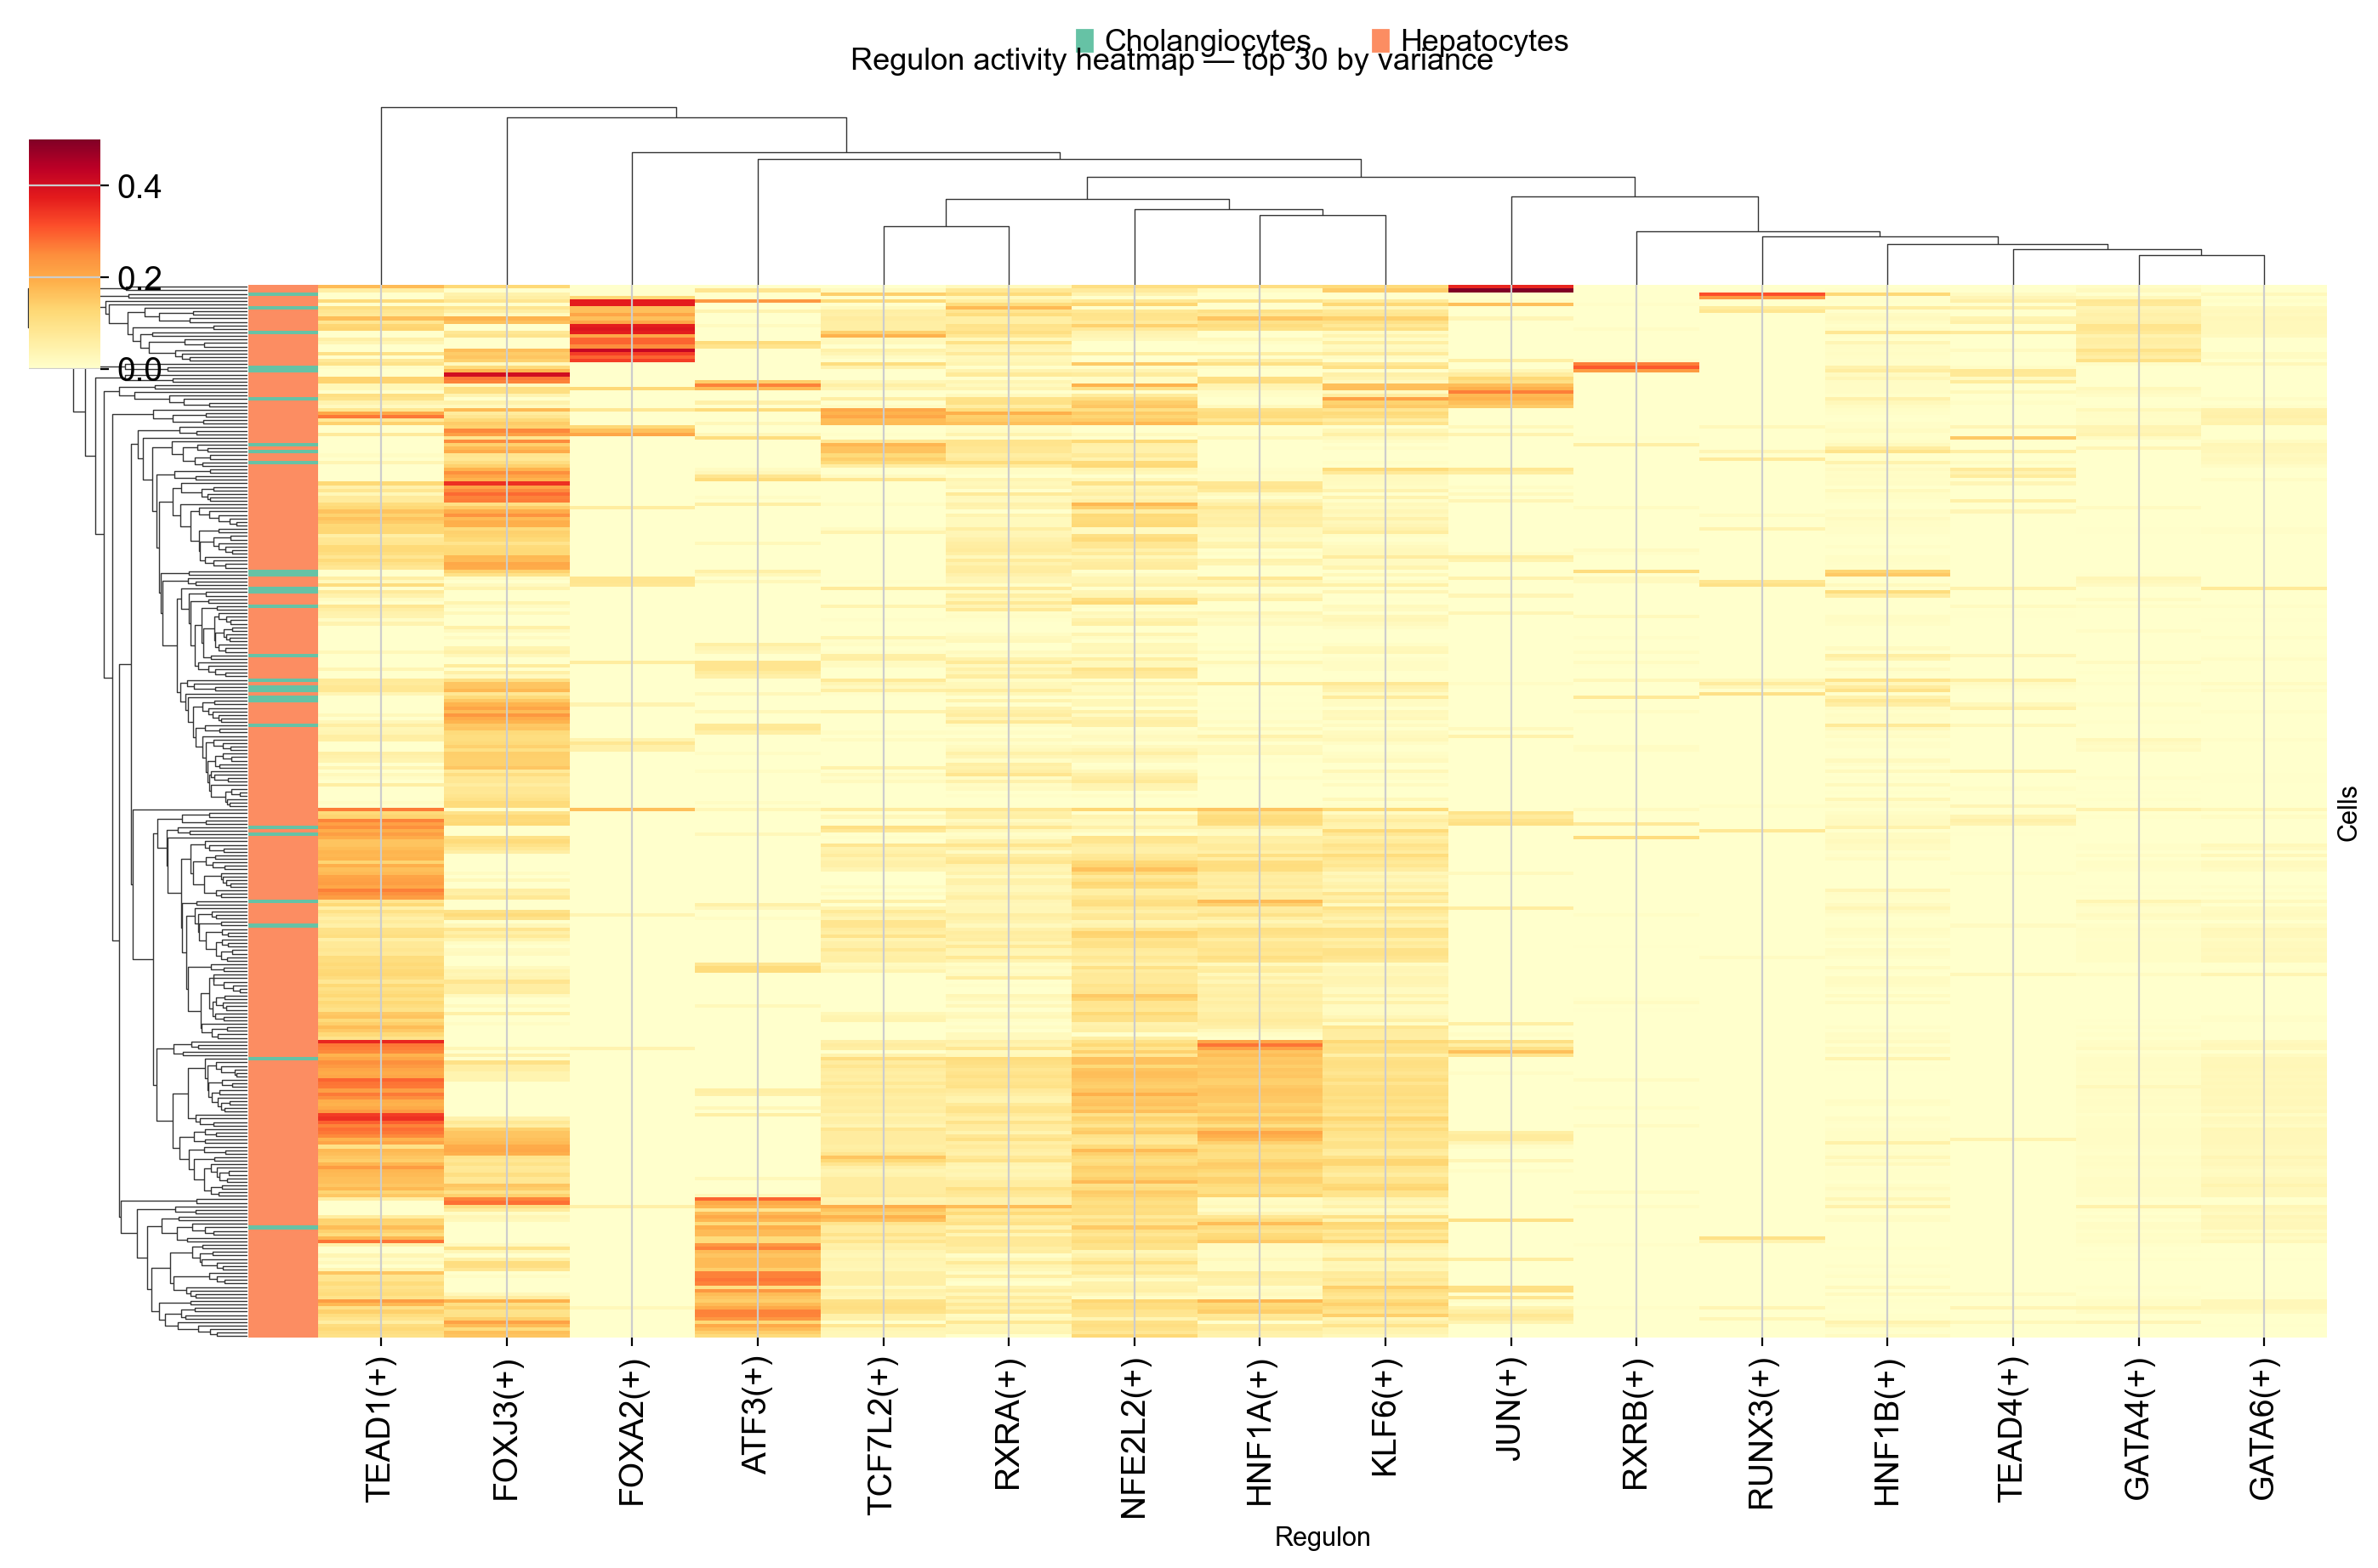

In [25]:
# ── Cell 11 replacement: regulon heatmap ─────────────────────────────────────
TOP_REGULONS = 30

# Flatten MultiIndex columns if present (pySCENIC sometimes produces these)
if isinstance(auc_mtx.columns, pd.MultiIndex):
    auc_mtx.columns = ["_".join(str(c) for c in col).strip() for col in auc_mtx.columns]

# Select top regulons by variance
top_reg = auc_mtx.var(axis=0).nlargest(TOP_REGULONS).index
plot_df = auc_mtx[top_reg].copy()

# Reset index to avoid MultiIndex on rows too
plot_df = plot_df.reset_index(drop=True)

# Row colours from cell annotation
cell_types = adata_scenic.obs["cell.annotation"].astype(str).values
palette_ct = dict(zip(sorted(set(cell_types)),
                      sns.color_palette("Set2", len(set(cell_types)))))
row_colors = pd.Series(cell_types).map(palette_ct).values

g = sns.clustermap(
    plot_df,
    row_colors       = row_colors,
    cmap             = "YlOrRd",
    figsize          = (14, 9),
    xticklabels      = True,
    yticklabels      = False,
    dendrogram_ratio = (0.1, 0.15),
    cbar_pos         = (0.02, 0.8, 0.03, 0.15),
)
g.ax_heatmap.set_xlabel("Regulon", fontsize=11)
g.ax_heatmap.set_ylabel("Cells", fontsize=11)
g.figure.suptitle(f"Regulon activity heatmap — top {TOP_REGULONS} by variance",
                  y=1.01, fontsize=13)

from matplotlib.patches import Patch
handles = [Patch(color=c, label=ct) for ct, c in palette_ct.items()]
g.ax_col_dendrogram.legend(handles=handles, loc="center", ncol=len(handles),
                            bbox_to_anchor=(0.5, 1.3), frameon=False)

plt.savefig(os.path.join(OUTPUT_DIR, "regulon_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Cell 12 · Visualisation 3 — Hepatocyte vs Cholangiocyte differential regulons

Which regulons are most specifically active in each cell type?  
We use a simple mean-difference approach (fast and interpretable).

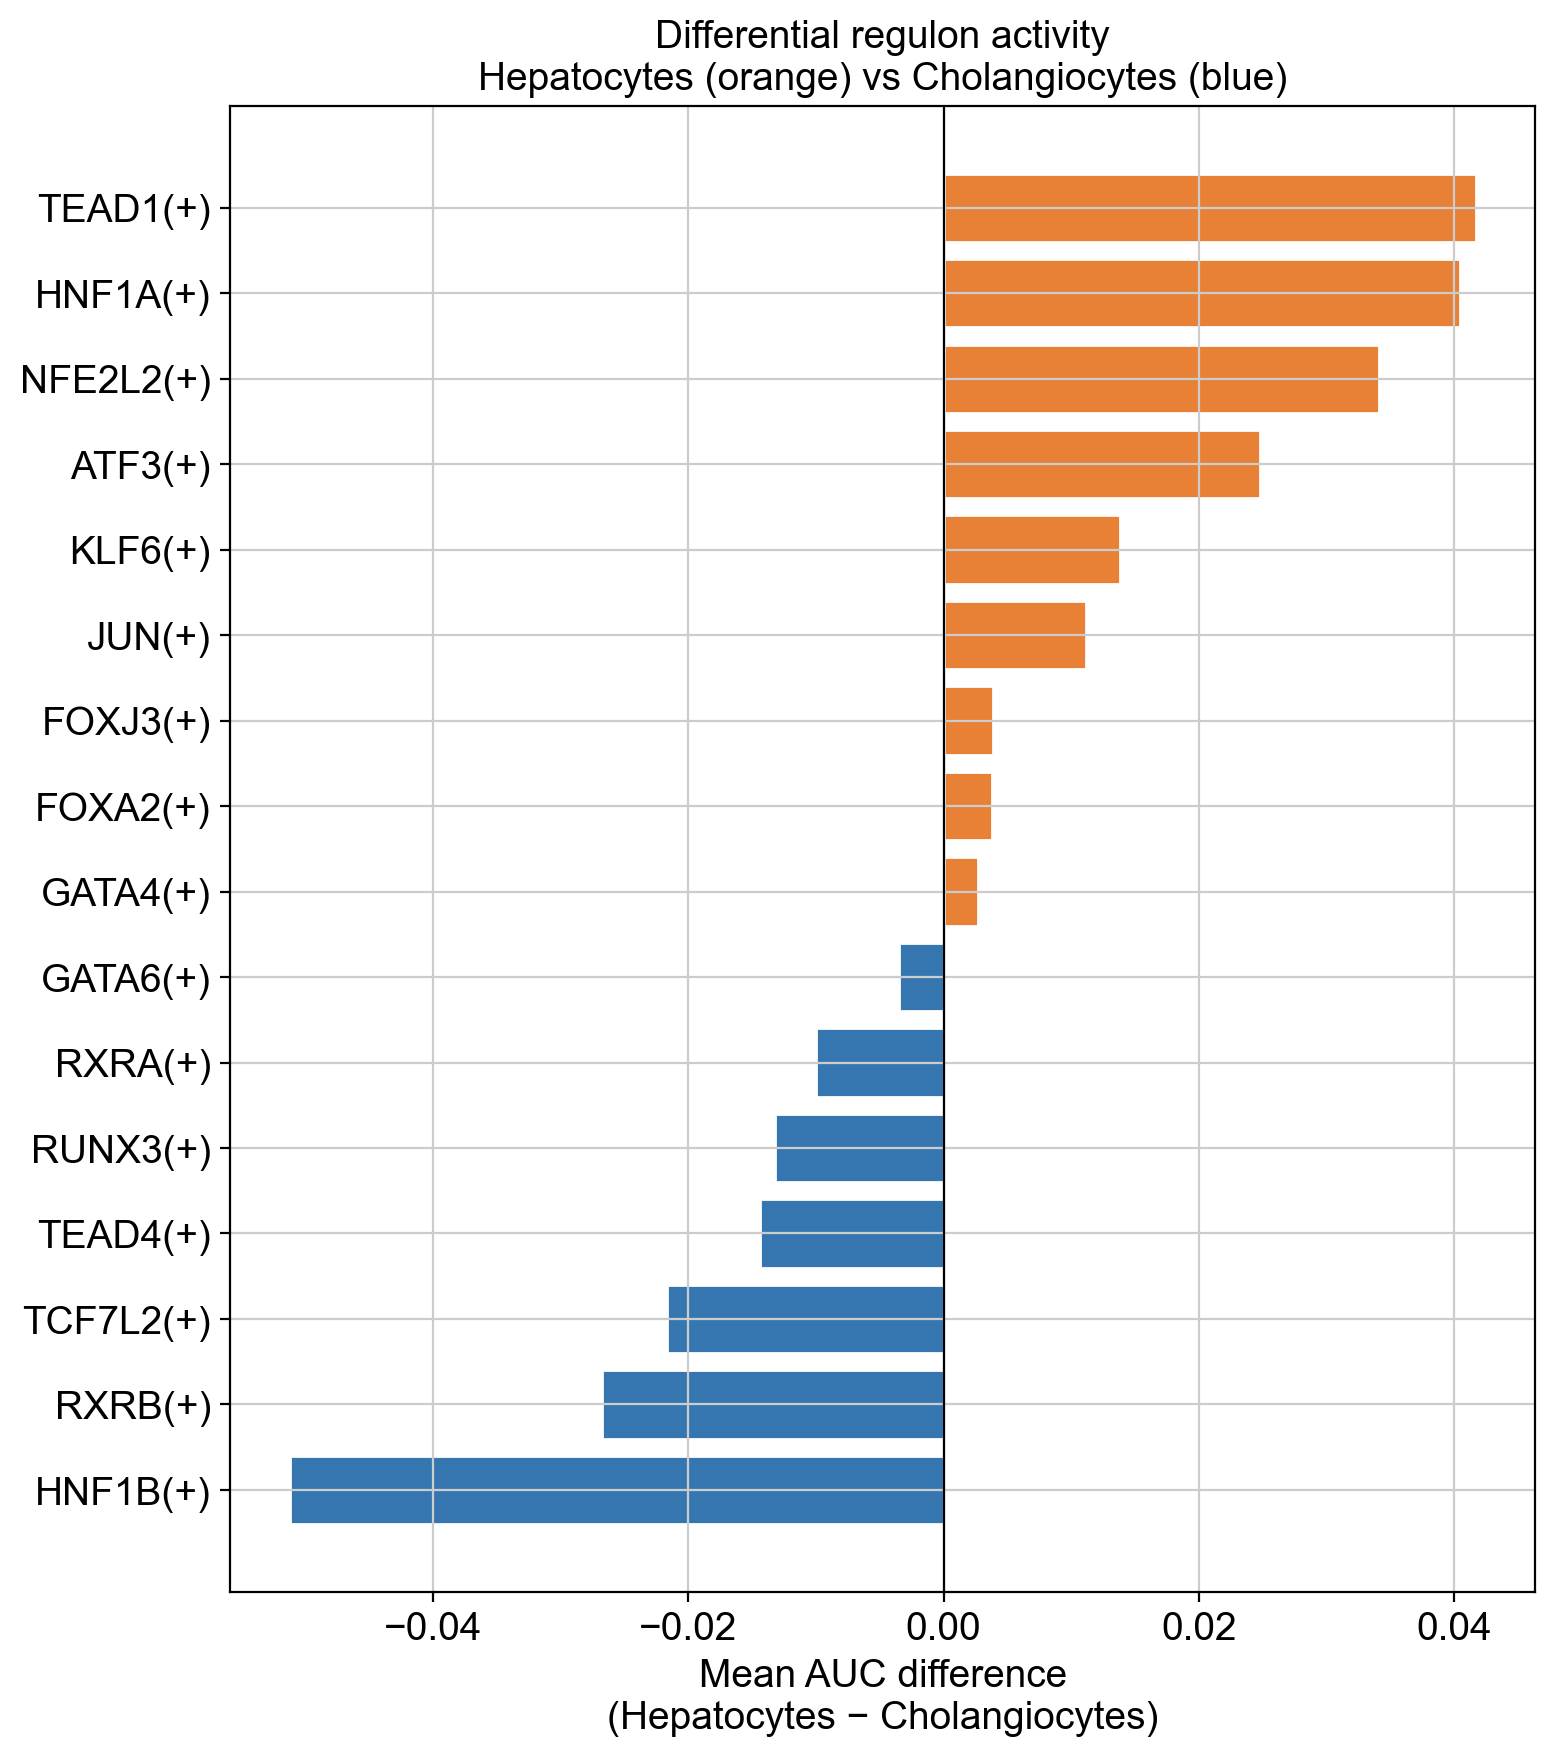


Top hepatocyte regulons:
           Hepatocytes  Cholangiocytes      diff
Regulon                                         
GATA6(+)      0.009655        0.013186 -0.003530
GATA4(+)      0.009681        0.006989  0.002692
FOXA2(+)      0.023735        0.019976  0.003759
FOXJ3(+)      0.084339        0.080479  0.003860
JUN(+)        0.019188        0.008060  0.011128
KLF6(+)       0.054786        0.040974  0.013812
ATF3(+)       0.038812        0.013982  0.024830
NFE2L2(+)     0.077102        0.042998  0.034104
HNF1A(+)      0.061718        0.021221  0.040497
TEAD1(+)      0.104176        0.062476  0.041701

Top cholangiocyte regulons:
           Hepatocytes  Cholangiocytes      diff
Regulon                                         
HNF1B(+)      0.008317        0.059568 -0.051251
RXRB(+)       0.002886        0.029684 -0.026797
TCF7L2(+)     0.038214        0.059881 -0.021667
TEAD4(+)      0.004952        0.019332 -0.014380
RUNX3(+)      0.004161        0.017379 -0.013218
RXRA(+)       

In [26]:
cell_ann = adata_scenic.obs["cell.annotation"]

# Mean AUC per regulon per cell type
hepato_mask    = cell_ann == "Hepatocytes"
cholangio_mask = cell_ann == "Cholangiocytes"

mean_hepato    = auc_mtx[hepato_mask].mean(axis=0)
mean_cholangio = auc_mtx[cholangio_mask].mean(axis=0)

diff_df = pd.DataFrame({
    "Hepatocytes"    : mean_hepato,
    "Cholangiocytes" : mean_cholangio,
    "diff"           : mean_hepato - mean_cholangio,   # positive = hepatocyte-enriched
}).sort_values("diff")

TOP_DIFF = 15   # top N each side

plot_diff = pd.concat([
    diff_df.head(TOP_DIFF),    # cholangiocyte-enriched (most negative diff)
    diff_df.tail(TOP_DIFF),    # hepatocyte-enriched (most positive diff)
])

colors = ["#3576b0" if v < 0 else "#e88035" for v in plot_diff["diff"]]

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(plot_diff.index, plot_diff["diff"], color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Mean AUC difference\n(Hepatocytes − Cholangiocytes)")
ax.set_title("Differential regulon activity\nHepatocytes (orange) vs Cholangiocytes (blue)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "differential_regulons.png"), dpi=150)
plt.show()

print("\nTop hepatocyte regulons:")
print(diff_df.tail(10)[["Hepatocytes", "Cholangiocytes", "diff"]].to_string())
print("\nTop cholangiocyte regulons:")
print(diff_df.head(10)[["Hepatocytes", "Cholangiocytes", "diff"]].to_string())

---
## Cell 13 · Visualisation 4 — UMAP coloured by key regulon activity

Plot the activity of specific liver TFs on the UMAP to see their spatial distribution.

Regulons found: ['HNF1A(+)', 'FOXA2(+)', 'HNF1B(+)']


c:\Users\Floarea\miniconda3\envs\scenic\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


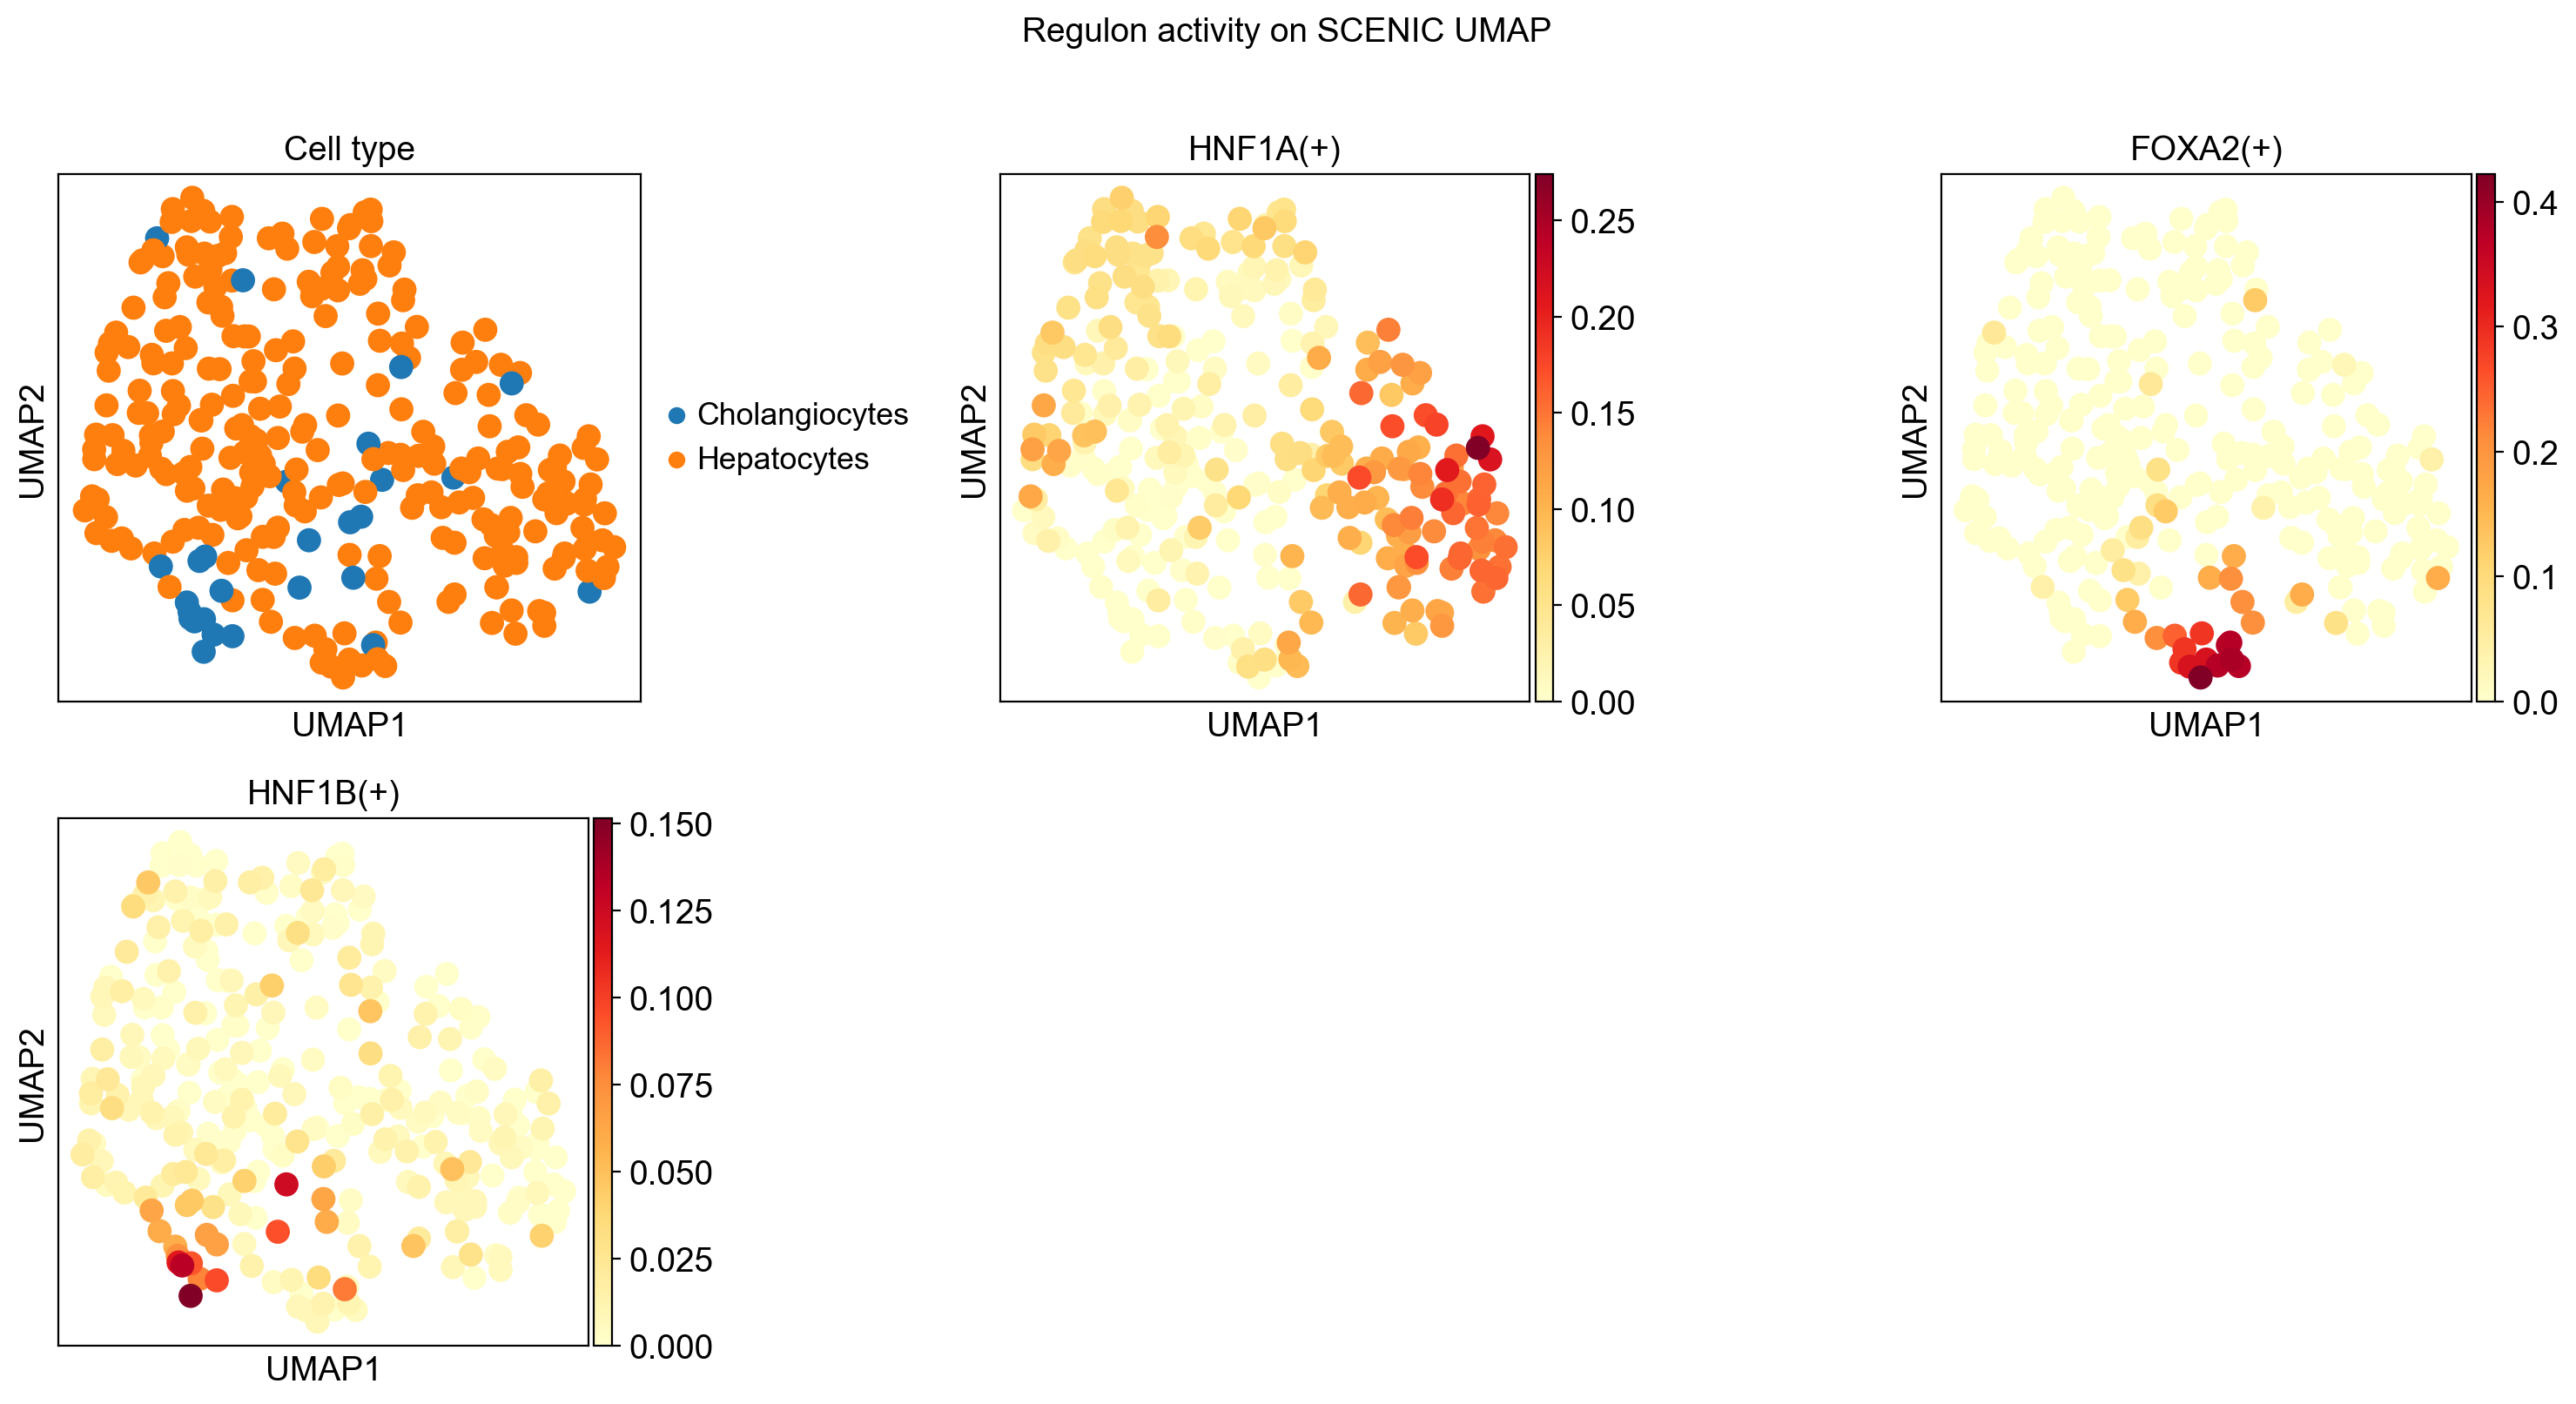

In [29]:
# ── Cell 13 replacement: UMAP coloured by key regulon activity ───────────────
KEY_TFS  = ["HNF4A", "HNF1A", "FOXA2", "SOX9", "HNF1B", "CEBPA"]
auc_cols = auc_mtx.columns.tolist()

# Find matching regulons
key_reg = []
for tf in KEY_TFS:
    matches = [c for c in auc_cols if c.startswith(tf)]
    key_reg.extend(matches)

print(f"Regulons found: {key_reg}")

if key_reg:
    # Sanitise names for scanpy: replace special characters with underscores
    # scanpy gets confused by parentheses in column names
    sanitised = {reg: reg.replace("(", "_").replace(")", "").replace("+", "pos")
                 for reg in key_reg}

    for reg, safe_name in sanitised.items():
        adata_auc.obs[safe_name] = auc_mtx[reg].reindex(adata_auc.obs_names).values

    plot_keys  = ["cell.annotation"] + list(sanitised.values())
    plot_titles = ["Cell type"] + list(sanitised.keys())   # original name as title

    n_cols = 3
    n_rows = int(np.ceil(len(plot_keys) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, (key, title) in enumerate(zip(plot_keys, plot_titles)):
        if i < len(axes):
            sc.pl.embedding(
                adata_auc, basis="umap", color=key,
                ax=axes[i], show=False,
                color_map="YlOrRd" if i > 0 else None,
                title=title,
            )

    for j in range(len(plot_keys), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Regulon activity on SCENIC UMAP", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "umap_key_regulons.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("None of the key TFs found. Available regulons:")
    print(auc_cols[:20])

---
## Cell 14 · Inspect regulon gene targets

For any TF of interest, inspect which genes are in its regulon  
and what their importance scores (from GRNBoost2) are.

In [30]:
TF_OF_INTEREST = "HNF4A"   # change to any TF in your regulons

# Find the matching regulon object
match = [r for r in regulons if r.name.startswith(TF_OF_INTEREST)]

if match:
    reg = match[0]
    print(f"Regulon: {reg.name}")
    print(f"Number of target genes: {len(reg.gene2weight)}")

    # Sort targets by weight (= motif enrichment score)
    targets_df = (
        pd.Series(reg.gene2weight, name="weight")
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={"index": "target_gene"})
    )
    print(f"\nTop 20 targets of {reg.name}:")
    print(targets_df.head(20).to_string(index=False))

    # Save full target list
    targets_df.to_csv(
        os.path.join(OUTPUT_DIR, f"{TF_OF_INTEREST}_targets.csv"),
        index=False
    )
else:
    print(f"{TF_OF_INTEREST} not found in regulons.")
    print("Available regulons:", [r.name for r in regulons[:20]])

HNF4A not found in regulons.
Available regulons: ['ATF3(+)', 'FOXA2(+)', 'FOXJ3(+)', 'GATA4(+)', 'GATA6(+)', 'HNF1A(+)', 'HNF1B(+)', 'JUN(+)', 'KLF6(+)', 'NFE2L2(+)', 'RUNX3(+)', 'RXRA(+)', 'RXRB(+)', 'TCF7L2(+)', 'TEAD1(+)', 'TEAD4(+)']


---
## Cell 15 · Compare pySCENIC vs Velorama

Both tools identified TF → target links; here we find the **overlap**  
— interactions supported by both co-expression + motif enrichment (SCENIC)  
AND Granger causality (Velorama).

Top 20% Velorama links : 1,230
Top 20% SCENIC links   : 1,401
Overlap (both tools)   : 190

Top overlapping TF–target pairs:
    TF     target
 HNF4A       FMO5
  RXRA      EFNA1
   MYC     IGSF21
 NR5A2      CLIC4
   SP3        CTH
 SMAD3     ADGRL2
  MAFK AL591043.2
NFE2L2     DNAJC6
 GATA6 AC117944.1
 STAT3       MUC1
CTNNB1 ATP1A1-AS1
 PPARA       ORC1
  KLF6   SLC25A33
MLXIPL      PLPP3
CTNNB1     IFI44L
 NR1H4 AC099788.1
   SP3 AL450992.1
 STAT3       SCP2
  ATF2 AL136234.1
   SP3     CCDC30


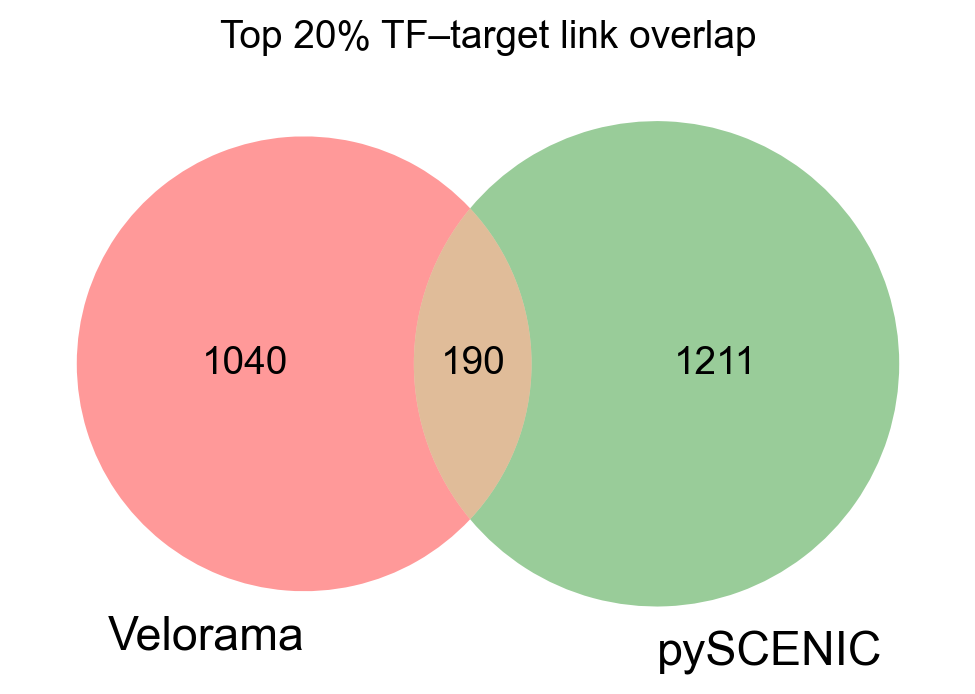

In [32]:
VELORAMA_GRN_PATH = r"C:/Users/Floarea/Desktop/corebioinfo/velorama_output/liver_endstage_grn_scores.csv"

if os.path.isfile(VELORAMA_GRN_PATH):
    # ── load Velorama results ─────────────────────────────────────────────────
    vel_df = pd.read_csv(VELORAMA_GRN_PATH, index_col=0)
    vel_long = (
        vel_df.stack()
        .reset_index()
        .rename(columns={"level_0": "TF", "level_1": "target", 0: "velorama_score"})
    )
    vel_long = vel_long[vel_long["TF"] != vel_long["target"]]

    # Top 20% Velorama links
    thresh_vel = vel_long["velorama_score"].quantile(0.80)
    vel_top    = set(zip(vel_long[vel_long["velorama_score"] >= thresh_vel]["TF"],
                         vel_long[vel_long["velorama_score"] >= thresh_vel]["target"]))

    # ── load SCENIC adjacencies (GRNBoost2 links before motif pruning) ────────
    thresh_adj = adjacencies["importance"].quantile(0.80)
    adj_top    = set(zip(adjacencies[adjacencies["importance"] >= thresh_adj]["TF"],
                         adjacencies[adjacencies["importance"] >= thresh_adj]["target"]))

    overlap = vel_top & adj_top

    print(f"Top 20% Velorama links : {len(vel_top):,}")
    print(f"Top 20% SCENIC links   : {len(adj_top):,}")
    print(f"Overlap (both tools)   : {len(overlap):,}")

    if overlap:
        overlap_df = pd.DataFrame(list(overlap), columns=["TF", "target"])
        overlap_df.to_csv(os.path.join(OUTPUT_DIR, "velorama_scenic_overlap.csv"), index=False)
        print(f"\nTop overlapping TF–target pairs:")
        print(overlap_df.head(20).to_string(index=False))

    # Venn diagram
    try:
        from matplotlib_venn import venn2
        fig, ax = plt.subplots(figsize=(6, 5))
        venn2([vel_top, adj_top],
              set_labels=("Velorama", "pySCENIC"), ax=ax)
        ax.set_title("Top 20% TF–target link overlap")
        plt.savefig(os.path.join(OUTPUT_DIR, "venn_overlap.png"), dpi=150)
        plt.show()
    except ImportError:
        print("(pip install matplotlib-venn for a Venn diagram)")
else:
    print(f"Velorama results not found at {VELORAMA_GRN_PATH}")
    print("Run the Velorama notebook first, or update the path above.")

---
## Cell 16 · Summary

| Output file | Description |
|---|---|
| `adjacencies.tsv` | Raw GRNBoost2 TF–target importance scores |
| `motifs.csv` | cisTarget motif enrichment table |
| `regulons.pkl` | Pruned regulon objects (pickle) |
| `auc_matrix.csv` | AUCell regulon activity matrix (cells × regulons) |
| `umap_scenic_space.png` | UMAP in regulon-activity space |
| `top_regulon_activity.png` | Bar chart: most active regulons |
| `regulon_heatmap.png` | Clustermap: cells × top regulons |
| `differential_regulons.png` | Hepatocyte vs Cholangiocyte regulon differences |
| `umap_key_regulons.png` | Key TF regulon activity on UMAP |
| `HNF4A_targets.csv` | Example: target genes of HNF4A regulon |
| `velorama_scenic_overlap.csv` | Interactions supported by both tools |

**Key differences vs Velorama:**
- pySCENIC uses **co-expression + motif enrichment** (binding evidence) → fewer but higher-confidence links
- Velorama uses **Granger causality on pseudotime** → captures temporal/causal directionality
- The overlap between both tools = highest-confidence regulatory interactions

**Next steps:**
- Validate top regulons in ChIP-seq data (ENCODE, ChEA3)
- Use `sc.pl.matrixplot` to show regulon activity across clusters
- Export to SCope viewer: `pyscenic export` to loom format